# Module 2: Epidemic Modeling 

## Team Members:
Amelia Luongo and Isabella Imburgia

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

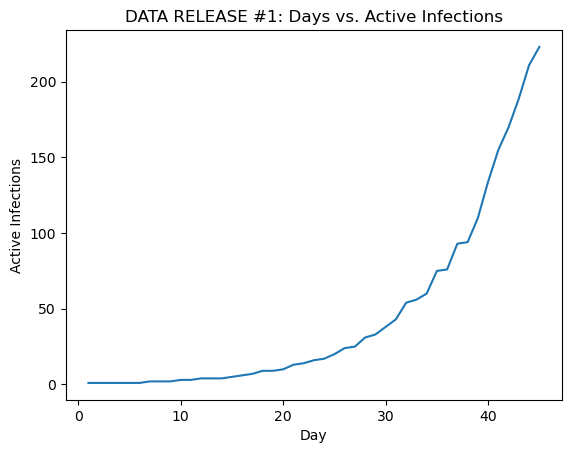

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# creating a graph that shows the number of active infections each day
df = pd.read_csv("/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv")

# Plot day vs active infections
plt.figure()
plt.plot(df["day"], df["active reported daily cases"])
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("DATA RELEASE #1: Days vs. Active Infections")
plt.show()


The initial infection spreads very slowly. There is only one active infection for the first 6 days of tracking, and only 2 infections for the following 3 days. The spread of the infection picks up a lot around day 30 and begins to look more like exponential growth. The growth rate can be modeled using a line of best fit from a regression model. Knowing more information such as the transmission rate, incubation rate, and recovery period would be helpful for determining the shape of the outbreak curve. This would help calculate the R0 value and figure out how many people are being infected from each sick person. It will also show how long it take for someone to move from an active infection to a recovered state, bringing the active cases back down.

Estimated R0 value: 1.8353473886658087


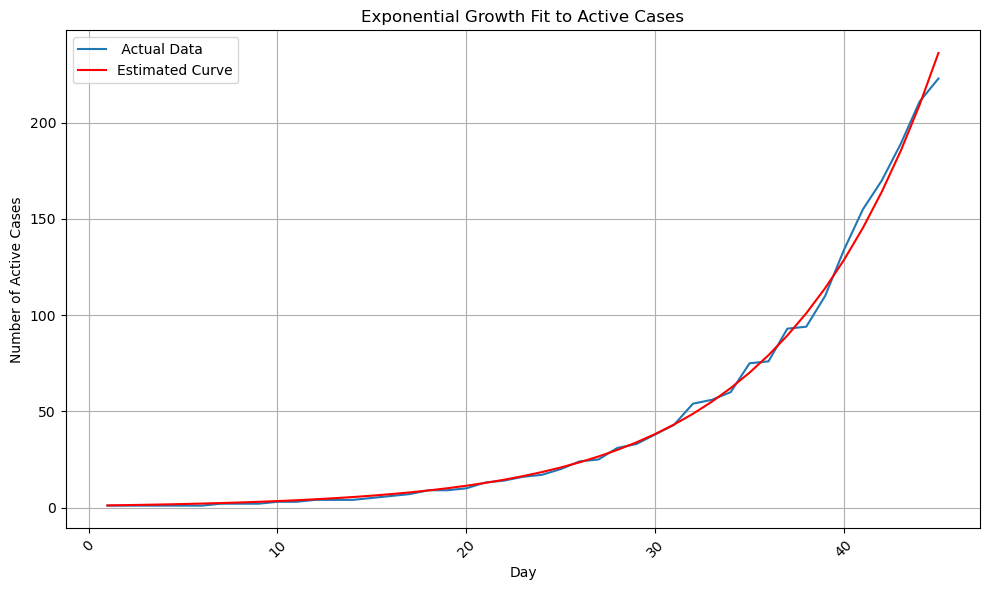

In [1]:
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = pd.read_csv('C:\\Users\\ajq2af\\OneDrive - University of Virginia\\Documents\\UVA\\BME 2315\\module2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Define a class to represent the virus data
#calculate the R0 value from early data csv file (first 45 days)
def eponential_growth(t,r):
    return np.exp(r*t)

x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(eponential_growth, x_data, y_data)
r_fit = popt[0]

D = 5 # estimated infection period from data 

r0 = np.exp(r_fit * D)

print("Estimated R0 value:", r0)
# add the fitted curve to the plot
y_fitted = eponential_growth(x_data, r_fit)
# plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label=' Actual Data')
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.title('Exponential Growth Fit to Active Cases')
plt.xlabel('Day')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

The estimated R0 value is 1.835. Other diseases that have a similar R0 value are Influenza (H1N1 2009) with an R0 value of 1.5 and Ebola with an R0 value of 2.0. The 2009 Influenza A strain was coined "swine flu" and spread rapidly throughout the globe through respiratory droplets. It had a relatively low fatality rate of 0.02% but was impactful enough that the World Health Organization declared a pandemic. While Ebola has a similar R0 value, it has a much higher ratality rate around 60%. It is transmitted through direct contact with infected bodily fluid and symptoms include fever, fatigue, vomiting/diarrhea, rash, and bleeding. Our R0 estimate at this stage is based on limited data, so it may not be accurate however it is a good estimate based on the data provided. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#%%
# Load the data
data = pd.read_csv(
    '/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv',
    parse_dates=['date']
)

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Euler SEIR function
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, dt=1):

    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in range(len(timepoints)-1):

        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S_new = S[-1] + dS * dt
        E_new = E[-1] + dE * dt
        I_new = I[-1] + dI * dt
        R_new = R[-1] + dR * dt

        S.append(S_new)
        E.append(E_new)
        I.append(I_new)
        R.append(R_new)

    return np.array(S), np.array(E), np.array(I), np.array(R)


# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()




### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [6]:
#%%
# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()

# Population size (larger so infections aren't capped)
N = 17000

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Parameter ranges
beta_range = np.linspace(0.01, 1, 30)
sigma_range = np.linspace(0.01, 1, 30)
gamma_range = np.linspace(0.01, 1, 30)

best_beta = None
best_sigma = None
best_gamma = None
best_SSE = np.inf

# Grid search
for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S, E, I, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)

            I_model = I[:len(data_I)]

            sse = np.sum((data_I - I_model)**2)

            if sse < best_SSE:
                best_SSE = sse
                best_beta = b
                best_sigma = s
                best_gamma = g

#%%
print("Best beta:", best_beta)
print("Best sigma:", best_sigma)
print("Best gamma:", best_gamma)
print("Best SSE:", best_SSE)


Best beta: 0.4537931034482759
Best sigma: 0.3513793103448276
Best gamma: 0.1806896551724138
Best SSE: 103649.51289822998


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

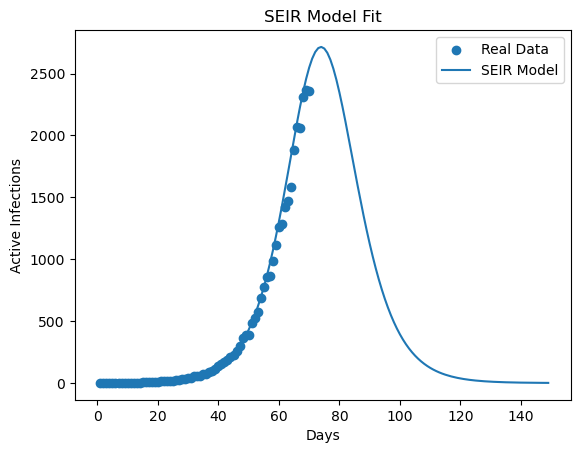

In [7]:
#%%
# Predict future outbreak
future_days = 150
timepoints_future = np.arange(0, future_days)

S, E, I, R = euler_seir(
    best_beta,
    best_sigma,
    best_gamma,
    S0,
    E0,
    I0,
    R0,
    timepoints_future,
    N
)

#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

#%%
# Plot results
plt.figure()

plt.scatter(
    data["day"],
    data["active reported daily cases"],
    label="Real Data"
)

plt.plot(
    timepoints_future,
    I,
    label="SEIR Model"
)

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model Fit")
plt.legend()

plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



In [8]:
#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

print("Peak infections:", peak_height)
print("Peak occurs on day:", peak_day)


Peak infections: 2715.0463016164344
Peak occurs on day: 74



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


Peak infections: 3643.5605253111385
Peak occurs on day: 80


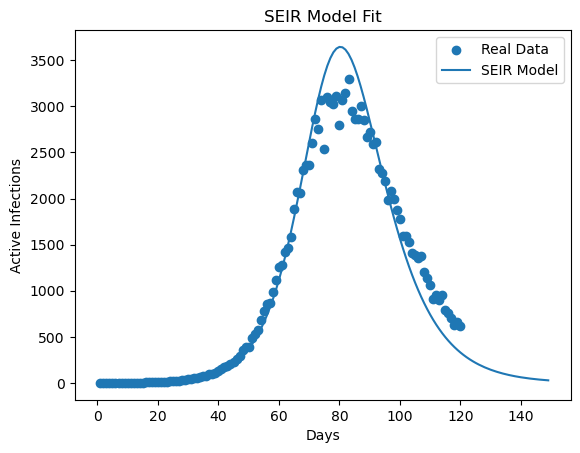

In [16]:
# Load the data
data = pd.read_csv(
    '/Users/amelialuongo/Desktop/comp bme/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv',
    parse_dates=['date']
)

#%%
# Euler SEIR function
def euler_seir(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, dt=1):

    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in range(len(timepoints)-1):

        dS = -beta * S[-1] * I[-1] / N
        dE = beta * S[-1] * I[-1] / N - sigma * E[-1]
        dI = sigma * E[-1] - gamma * I[-1]
        dR = gamma * I[-1]

        S_new = S[-1] + dS * dt
        E_new = E[-1] + dE * dt
        I_new = I[-1] + dI * dt
        R_new = R[-1] + dR * dt

        S.append(S_new)
        E.append(E_new)
        I.append(I_new)
        R.append(R_new)

    return np.array(S), np.array(E), np.array(I), np.array(R)

#%%
# Observed infected data
data_I = data["active reported daily cases"].to_numpy()
timepoints = data["day"].to_numpy()

# Population size (larger so infections aren't capped)
N = 17000

# Initial conditions
I0 = data_I[0]
E0 = 0
R0 = 1.835
S0 = N - I0

#%%
# Parameter ranges
beta_range = np.linspace(0.01, 1, 30)
sigma_range = np.linspace(0.01, 1, 30)
gamma_range = np.linspace(0.01, 1, 30)

best_beta = None
best_sigma = None
best_gamma = None
best_SSE = np.inf

# Grid search
for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S, E, I, R = euler_seir(b, s, g, S0, E0, I0, R0, timepoints, N)

            I_model = I[:len(data_I)]

            sse = np.sum((data_I - I_model)**2)

            if sse < best_SSE:
                best_SSE = sse
                best_beta = b
                best_sigma = s
                best_gamma = g

#%%
# Predict future outbreak
future_days = 150
timepoints_future = np.arange(0, future_days)

S, E, I, R = euler_seir(
    best_beta,
    best_sigma,
    best_gamma,
    S0,
    E0,
    I0,
    R0,
    timepoints_future,
    N
)

#%%
# Peak analysis
peak_height = np.max(I)
peak_day = np.argmax(I)

print("Peak infections:", peak_height)
print("Peak occurs on day:", peak_day)

#%%
# Plot results
plt.figure()

plt.scatter(
    data["day"],
    data["active reported daily cases"],
    label="Real Data"
)

plt.plot(
    timepoints_future,
    I,
    label="SEIR Model"
)

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model Fit")
plt.legend()

plt.show()

Actual peak infections: 3109 cases

Predicted peak: 3643.56 cases

Percent error: 17.19%

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



1. Immediate masking from day 70
2. Vaccine campaign
3. Vaccine rollout
4. Testing and quarantine
5. Close school for 2 weeks

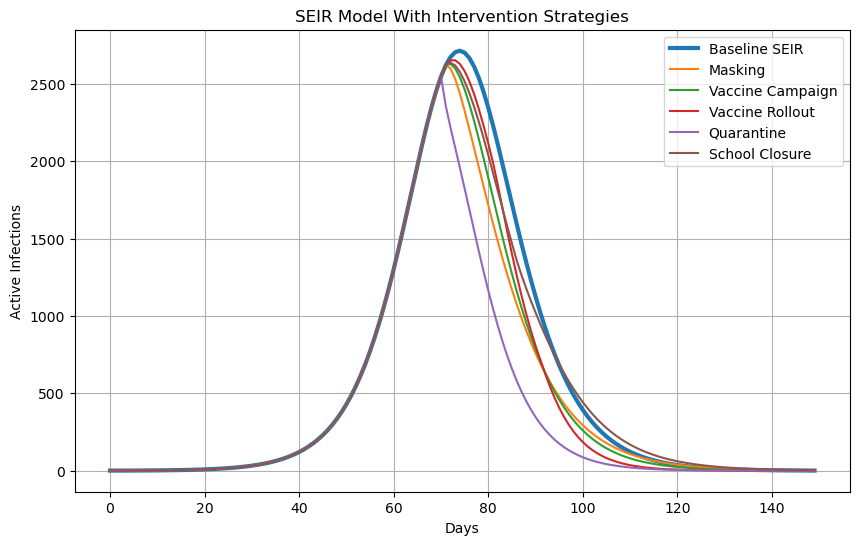

In [11]:
#%% INTERVENTION STRATEGIES

import numpy as np
import matplotlib.pyplot as plt

future_days = 150
timepoints_future = np.arange(0, future_days)

# -----------------------------
# Baseline SEIR (no intervention)
# -----------------------------

S_base = [S0]
E_base = [E0]
I_base = [I0]
R_base = [R0]

for t in range(future_days-1):

    dS = -best_beta * S_base[-1] * I_base[-1] / N
    dE = best_beta * S_base[-1] * I_base[-1] / N - best_sigma * E_base[-1]
    dI = best_sigma * E_base[-1] - best_gamma * I_base[-1]
    dR = best_gamma * I_base[-1]

    S_base.append(S_base[-1] + dS)
    E_base.append(E_base[-1] + dE)
    I_base.append(I_base[-1] + dI)
    R_base.append(R_base[-1] + dR)

S_base = np.array(S_base)
I_base = np.array(I_base)


# -----------------------------
# 1. MASKING (β reduced 40% after day 70)
# -----------------------------

S_mask = [S0]
E_mask = [E0]
I_mask = [I0]
R_mask = [R0]

for t in range(future_days-1):

    beta_current = best_beta

    if t >= 70:
        beta_current = best_beta * 0.6

    dS = -beta_current * S_mask[-1] * I_mask[-1] / N
    dE = beta_current * S_mask[-1] * I_mask[-1] / N - best_sigma * E_mask[-1]
    dI = best_sigma * E_mask[-1] - best_gamma * I_mask[-1]
    dR = best_gamma * I_mask[-1]

    S_mask.append(S_mask[-1] + dS)
    E_mask.append(E_mask[-1] + dE)
    I_mask.append(I_mask[-1] + dI)
    R_mask.append(R_mask[-1] + dR)

I_mask = np.array(I_mask)


# -----------------------------
# 2. VACCINE CAMPAIGN
# 1800 people vaccinated day 70
# -----------------------------

S_camp = [S0]
E_camp = [E0]
I_camp = [I0]
R_camp = [R0]

for t in range(future_days-1):

    if t == 70:
        S_camp[-1] -= 1800
        R_camp[-1] += 1800

    dS = -best_beta * S_camp[-1] * I_camp[-1] / N
    dE = best_beta * S_camp[-1] * I_camp[-1] / N - best_sigma * E_camp[-1]
    dI = best_sigma * E_camp[-1] - best_gamma * I_camp[-1]
    dR = best_gamma * I_camp[-1]

    S_camp.append(S_camp[-1] + dS)
    E_camp.append(E_camp[-1] + dE)
    I_camp.append(I_camp[-1] + dI)
    R_camp.append(R_camp[-1] + dR)

I_camp = np.array(I_camp)


# -----------------------------
# 3. VACCINE ROLLOUT
# 900 people vaccinated on 70,80,90
# -----------------------------

S_roll = [S0]
E_roll = [E0]
I_roll = [I0]
R_roll = [R0]

for t in range(future_days-1):

    if t in [70,80,90]:
        S_roll[-1] -= 900
        R_roll[-1] += 900

    dS = -best_beta * S_roll[-1] * I_roll[-1] / N
    dE = best_beta * S_roll[-1] * I_roll[-1] / N - best_sigma * E_roll[-1]
    dI = best_sigma * E_roll[-1] - best_gamma * I_roll[-1]
    dR = best_gamma * I_roll[-1]

    S_roll.append(S_roll[-1] + dS)
    E_roll.append(E_roll[-1] + dE)
    I_roll.append(I_roll[-1] + dI)
    R_roll.append(R_roll[-1] + dR)

I_roll = np.array(I_roll)


# -----------------------------
# 4. QUARANTINE
# infection period shortened by 2 days after day 70
# -----------------------------

infection_period = 1 / best_gamma
gamma_quarantine = 1 / (infection_period - 2)

S_quar = [S0]
E_quar = [E0]
I_quar = [I0]
R_quar = [R0]

for t in range(future_days-1):

    gamma_current = best_gamma

    if t >= 70:
        gamma_current = gamma_quarantine

    dS = -best_beta * S_quar[-1] * I_quar[-1] / N
    dE = best_beta * S_quar[-1] * I_quar[-1] / N - best_sigma * E_quar[-1]
    dI = best_sigma * E_quar[-1] - gamma_current * I_quar[-1]
    dR = gamma_current * I_quar[-1]

    S_quar.append(S_quar[-1] + dS)
    E_quar.append(E_quar[-1] + dE)
    I_quar.append(I_quar[-1] + dI)
    R_quar.append(R_quar[-1] + dR)

I_quar = np.array(I_quar)


# -----------------------------
# 5. SCHOOL CLOSURE
# reduce contacts by 20% days 70-84
# -----------------------------

S_school = [S0]
E_school = [E0]
I_school = [I0]
R_school = [R0]

for t in range(future_days-1):

    beta_current = best_beta

    if 70 <= t <= 84:
        beta_current = best_beta * 0.8

    dS = -beta_current * S_school[-1] * I_school[-1] / N
    dE = beta_current * S_school[-1] * I_school[-1] / N - best_sigma * E_school[-1]
    dI = best_sigma * E_school[-1] - best_gamma * I_school[-1]
    dR = best_gamma * I_school[-1]

    S_school.append(S_school[-1] + dS)
    E_school.append(E_school[-1] + dE)
    I_school.append(I_school[-1] + dI)
    R_school.append(R_school[-1] + dR)

I_school = np.array(I_school)


# -----------------------------
# Plot comparison
# -----------------------------

plt.figure(figsize=(10,6))

plt.plot(timepoints_future, I_base, label="Baseline SEIR", linewidth=3)
plt.plot(timepoints_future, I_mask, label="Masking")
plt.plot(timepoints_future, I_camp, label="Vaccine Campaign")
plt.plot(timepoints_future, I_roll, label="Vaccine Rollout")
plt.plot(timepoints_future, I_quar, label="Quarantine")
plt.plot(timepoints_future, I_school, label="School Closure")

plt.xlabel("Days")
plt.ylabel("Active Infections")
plt.title("SEIR Model With Intervention Strategies")
plt.legend()
plt.grid()

plt.show()

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*